# Tarea 1 
### Matías Arriagada R. | 2022445068 | matiaarriagada2022@udec.cl

Esta tarea fue realizada a partir de los datos suministrados por el profesor y los alumnos ayudantes. Se utilizo Inteligencia Artificial para realizar el codigo, la interpretación fue realizada en base a los conocimientos adquiridos en clases teoricas y prácticas. 

# 1. cargar base de datos, identificación de variables y tratamiento. 

In [39]:
# Importamos las librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import statsmodels.formula.api as smf
# Ajustamos la librería de stargazer para mostrar los resultados de los modelos
from stargazer.stargazer import Stargazer
from IPython.core.display import HTML


## Tratamiento a los datos
Anteriormente a ejecutar el codigo completo, se pudo observar usando data wrangler, que existe una columna llamada "drug_use" que estaba con casi la mitad de los datos faltantes, se utilizo el criterio de eliminación para eso. Para datos respectivos con más de 5 columnas vacías se decidió eliminarlas para evitar imputar con datos que tal vez no aporten una solución real a los datos. 

(5621, 22)


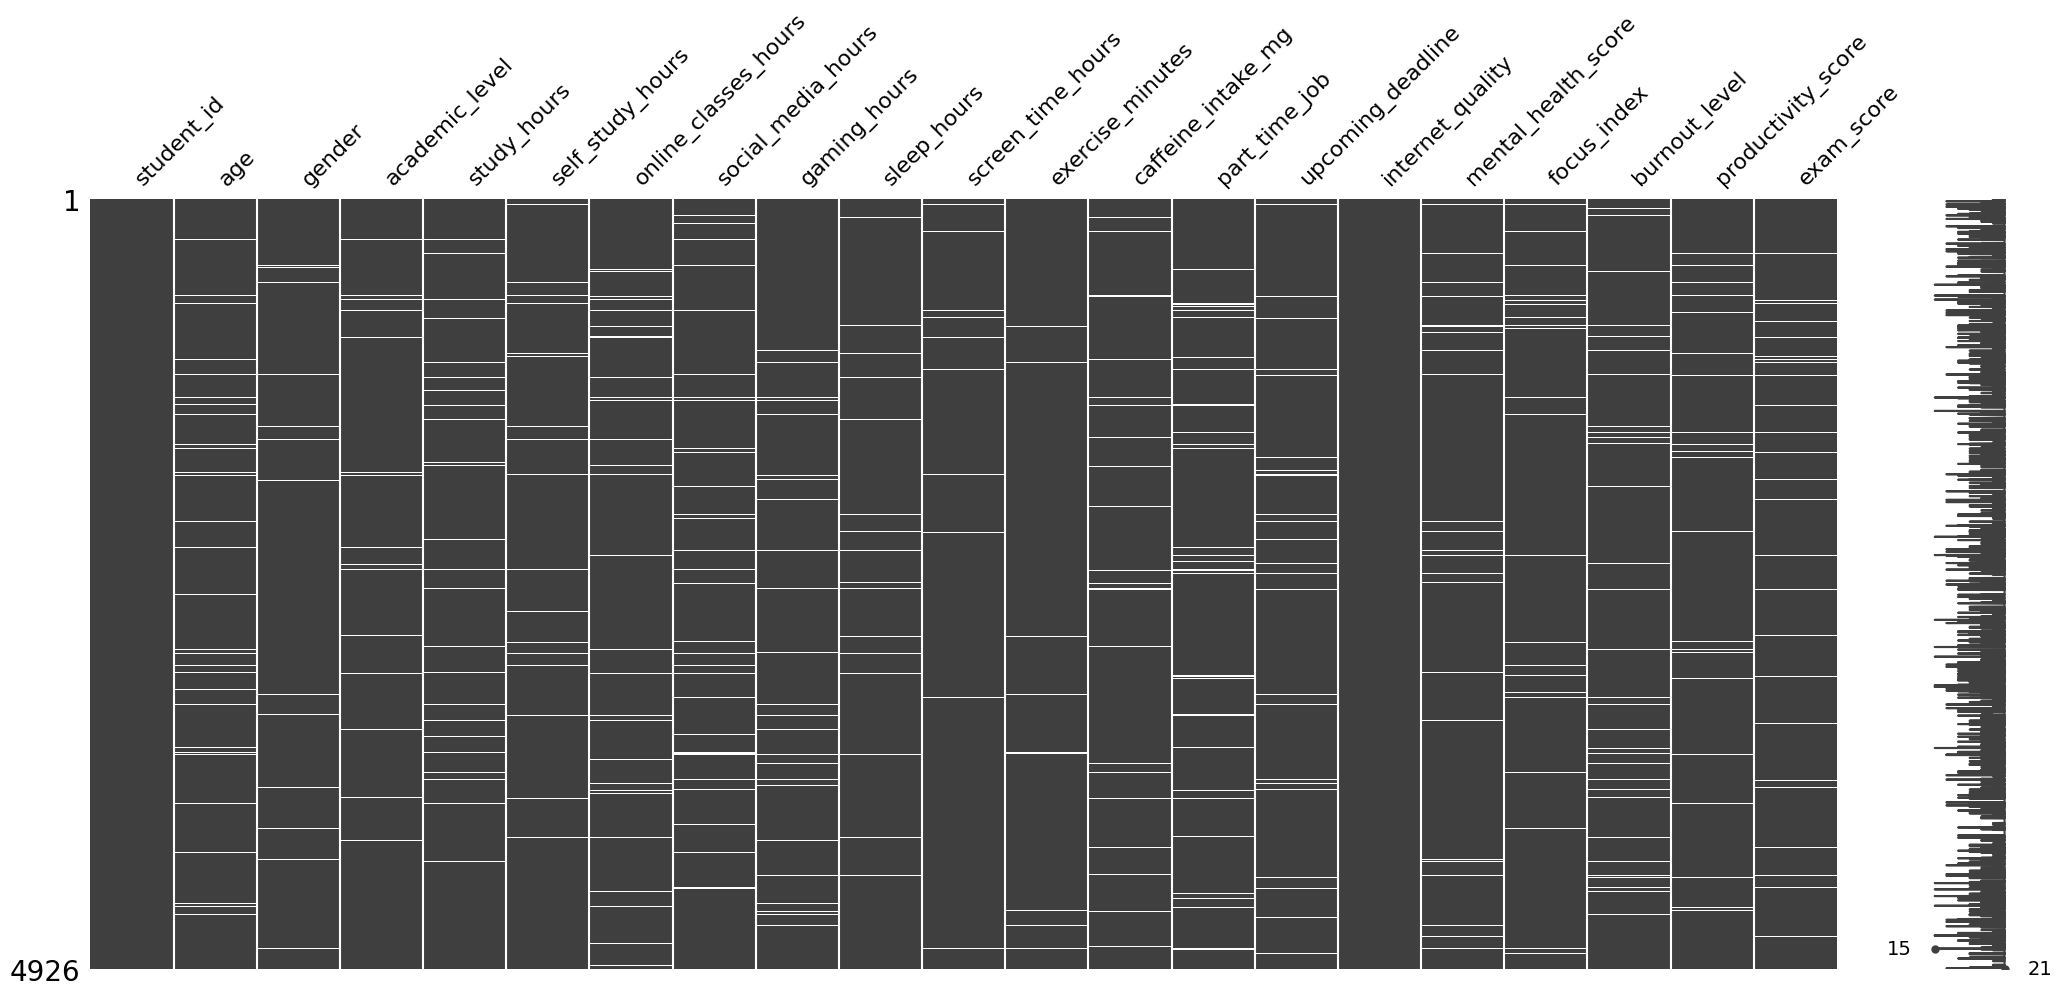

In [40]:
#realizamos la lectura del dataset
df = pd.read_csv("student_productivity.csv")
#Copiare el dataframe para no modificar el original
data = df.copy()
# Eliminaría la columna de drug use debido a que esta practicamente no tiene datos y no aportaría nada al análisis
data.drop('drug_use', axis=1, inplace=True)
#Eliminaría las filas que están vacías debido a que no aportan nada al análisis y podrían afectar los resultados, pero solo las que tienen toda la fila vacía, ya que si solo tienen una o dos columnas vacías podrían ser rellenadas con la media o la moda dependiendo del tipo de dato.
data.dropna(how='all', inplace=True) #No sirvió eliminar las filas vacías, ya que no hay filas vacías, por lo que se eliminaron las filas que tienen más de 5 columnas vacías, ya que estas filas no aportan nada al análisis y podrían afectar los resultados.
#Eliminaría las filas que tienen más de 5 columnas vacías, ya que estas filas no aportan nada al análisis y podrían afectar los resultados.
data.dropna(thresh=data.shape[1]-6, inplace=True)
# para internet_quality eliminaremos los NaN
data = data.dropna(subset=['internet_quality'])
print(df.shape)

#Veemos el gráfico de missingno para ver los datos faltantes
msno.matrix(data)
plt.show()

In [41]:
## Revisamos el comportamiento de las variables numéricas
data.describe()


,student_id,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,caffeine_intake_mg,upcoming_deadline,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
count,4926.000000,4766.000000,4808.000000,4787.000000,4782.000000,4778.000000,4789.000000,4841.000000,4868.000000,4812.000000,4785.000000,4795.000000,4783.000000,4768.000000,4832.000000,4747.000000
mean,2800.791717,20.510491,4.533852,2.480727,2.009258,2.999548,1.568050,7.019632,6.984665,251.254988,0.499687,5.511575,29.432084,45.624312,37.302256,18.870929
std,1623.992039,2.864955,1.819967,1.175765,0.985594,1.471163,1.111948,1.163075,2.484508,143.856737,0.500052,2.875171,9.978978,14.251814,16.849208,12.152109
min,1.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1391.250000,18.000000,3.257500,1.660000,1.310000,1.990000,0.670000,6.240000,5.280000,129.000000,0.000000,3.000000,22.560000,35.727500,25.372500,9.400000
50%,2789.500000,20.000000,4.530000,2.480000,2.010000,2.980000,1.490000,7.010000,6.950000,252.000000,0.000000,5.000000,29.430000,45.630000,36.865000,18.010000
75%,4215.750000,23.000000,5.760000,3.280000,2.680000,4.030000,2.350000,7.820000,8.710000,375.000000,1.000000,8.000000,36.230000,55.362500,49.172500,27.465000
max,5621.000000,25.000000,11.840000,7.410000,6.000000,8.280000,5.640000,10.000000,15.300000,499.000000,1.000000,10.000000,63.480000,97.580000,98.020000,64.090000


## Criterios de imputación utilizados en la limpieza de datos

#### Consideraciones previas
- La variable `age` tiene un rango válido de 16 a 25 años, por lo que imputar con la media es razonable.
- Las variables `study_hours`, `self_study_hours` y `online_classes_hours` son de tipo flotante y presentan distribuciones que justifican el uso de media o mediana según el caso.
- Se ha priorizado la robustez frente a outliers usando mediana cuando la distribución lo sugiere.

#### Variables imputadas con la media
Se eligió la media porque estas variables muestran distribuciones simétricas o media y mediana prácticamente iguales:

- `age`
- `study_hours`
- `self_study_hours`
- `online_classes_hours`
- `sleep_hours`
- `screen_time_hours`
- `focus_index`
- `burnout_level`

#### Variables imputadas con la mediana
Se prefirió la mediana para minimizar el impacto de posibles valores atípicos o asimetrías leves:

- `social_media_hours`
- `gaming_hours`
- `caffeine_intake_mg`
- `mental_health_score`
- `productivity_score`

#### Variable imputada con la moda
- `upcoming_deadline` (variable binaria, se usó el valor más frecuente)

#### Resumen en tabla

| Método | Variables |
|--------|-----------|
| **Media** | age, study_hours, self_study_hours, online_classes_hours, sleep_hours, screen_time_hours, focus_index, burnout_level |
| **Mediana** | social_media_hours, gaming_hours, caffeine_intake_mg, mental_health_score, productivity_score |
| **Moda**   | upcoming_deadline |

## Limpieza de datos
A continuación realizaremos la limpieza de datos, se utilizará el criterio de imputar datos con la media para datos que tengan una distribución mucho más limpia por así decirlo y la mediana para datos que tengan mayor varianza, para el caso de las variables categóricas se decidirá el utilizar la moda. Todos estos criterios son realizados a partir de la falta del 10% de los datos o que no signifiquen una cantidad que pueda causar cierto sesgo al momento de realizar los modelos.

In [42]:
#Datos con la media para estos datos: - `age`, `study_hours``self_study_hours``online_classes_hours``sleep_hours``screen_time_hours``focus_index``burnout_level`
#Añade con 2 decimales

# Permite activar/desactivar el redondeo de imputaciones a 2 decimales
redondear = True
decimales = 2

columnas_media = ['age', 'study_hours', 'self_study_hours', 'online_classes_hours', 'sleep_hours', 'screen_time_hours', 'focus_index', 'burnout_level']
for col in columnas_media:
    valor = data[col].mean()
    if redondear:
        valor = round(valor, decimales)
    data[col].fillna(valor, inplace=True)

#Datos con la mediana
columnas_mediana = ['social_media_hours', 'caffeine_intake_mg', 'mental_health_score', 'productivity_score',] #Por la caracteristicas de los datos las gaming hours es mejor no incorporarlas
for col in columnas_mediana:
    valor = data[col].median()
    if redondear:
        valor = round(valor, decimales)
    data[col].fillna(valor, inplace=True)

# Si se quiere mantener todas las columnas numéricas con 2 decimales tras imputar
if redondear:
    data[columnas_media + columnas_mediana] = data[columnas_media + columnas_mediana].round(decimales)

#Datos con la moda "upcoming_deadeline"
data['upcoming_deadline'].fillna(data['upcoming_deadline'].mode()[0], inplace=True)
data["internet_quality"] = data["internet_quality"].astype(str)
moda = data['internet_quality'].mode()[0]
data['internet_quality'].fillna(moda, inplace=True)

# Normalización previa (opcional)
data['gender'] = data['gender'].str.lower().map({
    'Male': 'Male',
    'Female': 'Female',
}).fillna('Other')

#Rellenamos con la media lo que sería para academic grade
data['academic_level'].fillna(data['academic_level'].mode()[0], inplace=True)

#Quitamos el min a la variable exercise_minutes y solo lo dejamos en datos enteros
data['exercise_minutes'] = data['exercise_minutes'].str.extract(r'(\d+\.?\d*)').astype(float)



C:\Users\Matias Arriagada R\AppData\Local\Temp\ipykernel_28528\463152142.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(valor, inplace=True)
C:\Users\Matias Arriagada R\AppData\Local\Temp\ipykernel_28528\463152142.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a

C:\Users\Matias Arriagada R\AppData\Local\Temp\ipykernel_28528\1679447269.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['exercise_minutes'].fillna(mediana, inplace=True)
C:\Users\Matias Arriagada R\AppData\Local\Temp\ipykernel_28528\1679447269.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values 


Info después de imputar:
<class 'pandas.core.series.Series'>
Index: 4926 entries, 0 to 5620
Series name: part_time_job
Non-Null Count  Dtype 
--------------  ----- 
4926 non-null   object
dtypes: object(1)
memory usage: 77.0+ KB
None
count    4747.000000
mean       18.870929
std        12.152109
min         1.000000
25%         9.400000
50%        18.010000
75%        27.465000
max        64.090000
Name: exam_score, dtype: float64
exam_score_group
2-30      3411
31-65      912
0-1        424
66-100       0
Name: count, dtype: int64


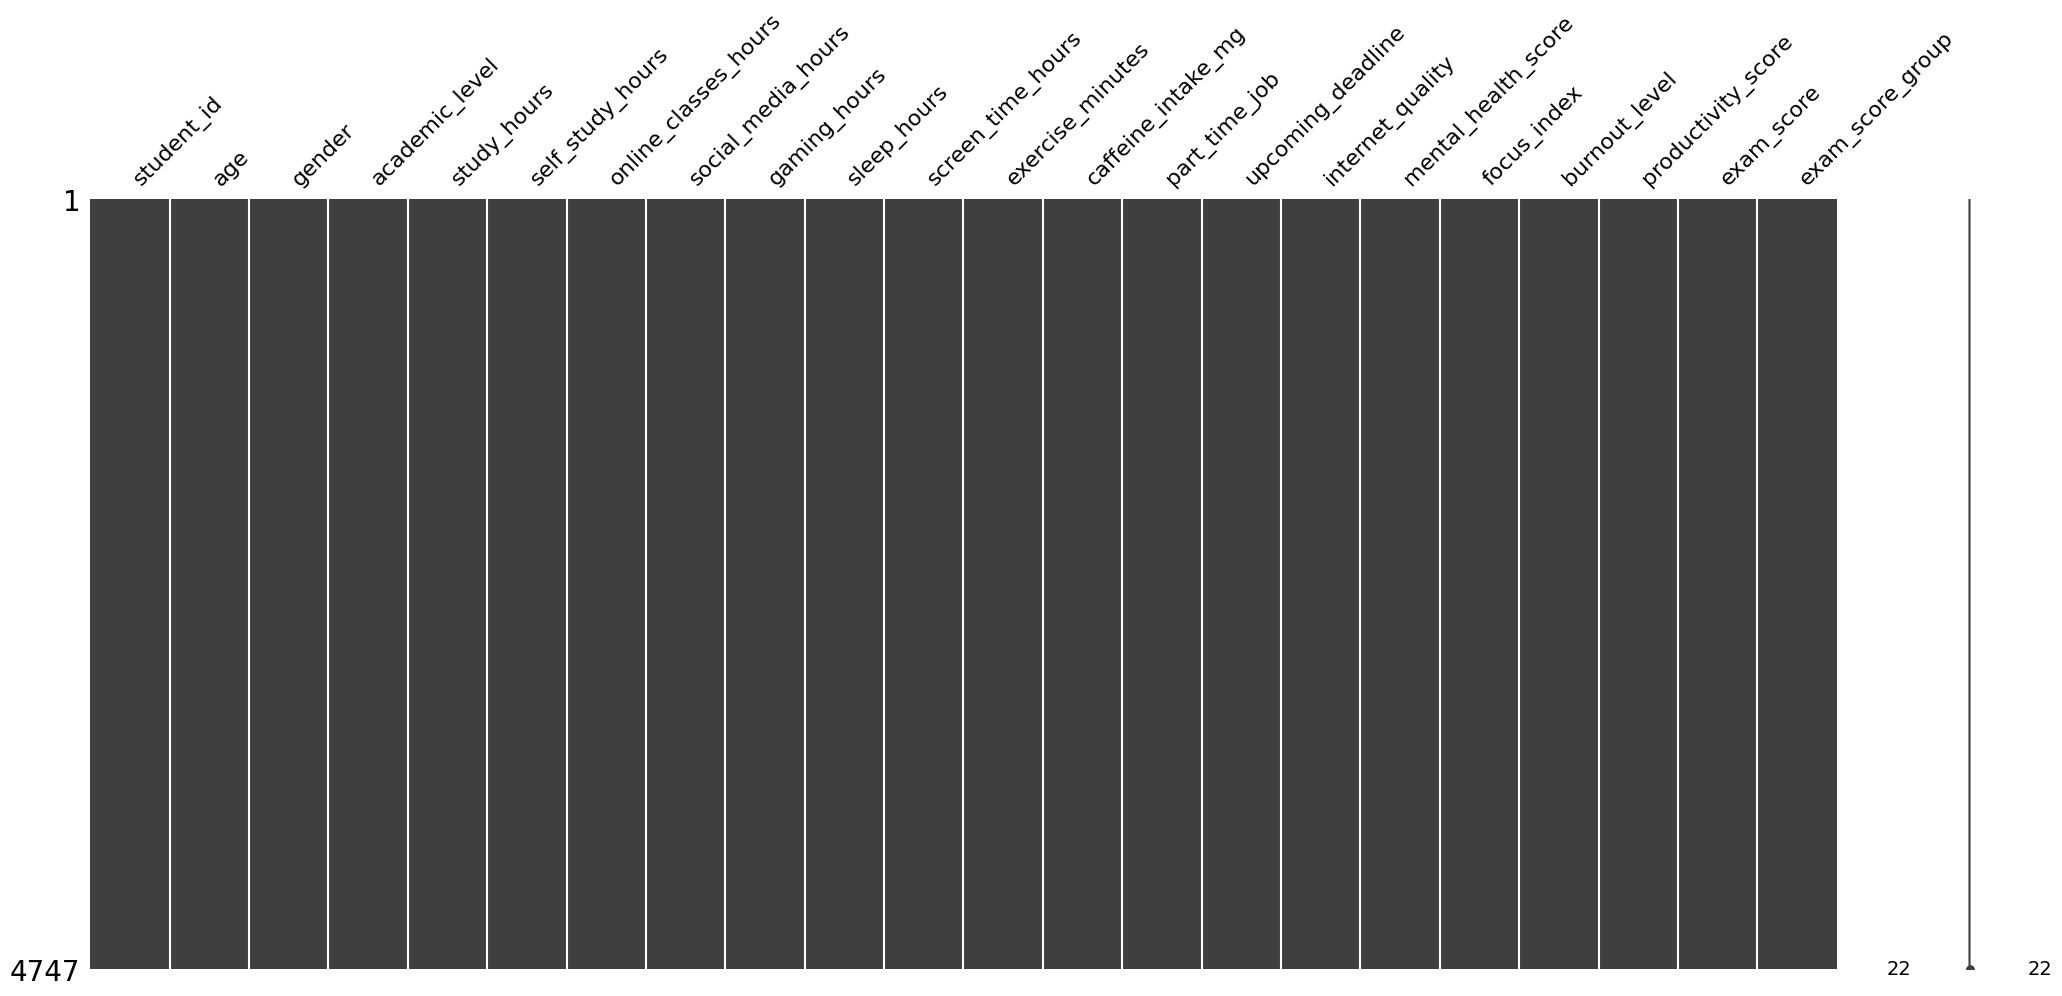

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,drug_use,focus_index,burnout_level,productivity_score,exam_score
0,1,20.0,NaN,Undergraduate,5.37,2.09,1.85,3.66,2.32,7.73,...,475.0,No,0.0,Good,3.0,NaN,19.01,31.77,42.59,25.08
1,2,16.0,Female,High School,5.85,5.04,1.87,3.60,2.79,6.11,...,362.0,no,0.0,Good,10.0,NaN,42.10,45.89,67.15,37.83
2,3,18.0,Female,Undergraduate,5.69,2.27,0.00,2.93,3.94,7.11,...,200.0,No,0.0,Average,5.0,NaN,21.93,37.07,37.68,18.66
3,4,24.0,Male,Undergraduate,2.32,1.06,2.30,4.34,2.37,8.54,...,233.0,No,1.0,Poor,3.0,1.0,13.47,43.63,12.83,1.00
4,5,24.0,Female,Postgraduate,3.87,2.63,2.54,3.71,1.30,7.69,...,159.0,No,1.0,Poor,2.0,NaN,19.95,56.62,18.53,7.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5616,5617,21.0,Male,Postgraduate,4.16,0.00,1.27,4.01,3.41,8.07,...,152.0,no,1.0,Poor,7.0,NaN,21.78,48.07,43.06,17.15
5617,5618,25.0,Female,NaN,NaN,NaN,NaN,5.18,NaN,NaN,...,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,42.52,21.06
5618,5619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5619,5620,NaN,NaN,NaN,NaN,NaN,NaN,3.52,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
data['exercise_minutes'] = data['exercise_minutes'].astype(str)  # asegurar string
data['exercise_minutes'] = data['exercise_minutes'].str.replace('min', '', regex=False)
data['exercise_minutes'] = data['exercise_minutes'].str.strip()
data['exercise_minutes'] = data['exercise_minutes'].str.replace(',', '.')
data['exercise_minutes'] = pd.to_numeric(data['exercise_minutes'], errors='coerce')


mediana = data['exercise_minutes'].median()
mediana = round(mediana)   # si quieres entero

# 4. Imputar valores faltantes
data['exercise_minutes'].fillna(mediana, inplace=True)

# 5. (Opcional) convertir a entero si todos los valores son enteros o no importan decimales
data['exercise_minutes'] = data['exercise_minutes'].astype(int)
#Pasamos la data a hora
data["exercise_minutes"] = data["exercise_minutes"]/60
data["exercise_minutes"] = data["exercise_minutes"].round(2)

#Tenemos problemas con lo que es la variable gaming hours y part time job
data["gaming_hours"].describe()
data["gaming_hours"] = data["gaming_hours"].fillna(data['gaming_hours'].median(), inplace=False)
data["gaming_hours"] = data["gaming_hours"].round(2)

#Ahora seguimos con los part_time_job
# 2. Convertir a string (por si hay mezcla de tipos)
data["part_time_job"] = data["part_time_job"].astype(str)

# 3. Reemplazar el string 'nan' por NaN real (pd.NA o np.nan)
data["part_time_job"] = data["part_time_job"].replace('nan', pd.NA)

# 4. Normalizar mayúsculas: 'yes'/'Yes' -> 'Yes', 'no'/'No' -> 'No'
data["part_time_job"] = data["part_time_job"].str.capitalize()  # Convierte 'yes' a 'Yes', 'no' a 'No'

# 5. Verificar resultado después de normalizar
moda = data["part_time_job"].mode()[0]
data["part_time_job"].fillna(moda, inplace=True)

# 6. Aproximaremos los valores de edad
data["age"] = data["age"].apply(np.trunc)

# 7. Revise que los valores de academic_level tienen un espacio al final
data["academic_level"] = data["academic_level"].str.strip()

# 8. Aproximaremos los valores de edad
data["upcoming_deadline"] = data["upcoming_deadline"].apply(np.trunc)

print("\nInfo después de imputar:")
print(data["part_time_job"].info())

#Observare a priori la variabl que es la queremos analizar que es el exam_score
print(data["exam_score"].describe())

#Sacamos los NaN de lo que es el exam_score para poder analizarlo mejor
data = data.dropna(subset=['exam_score'])

#Le haré una masacra para ver la distribución de los datos, los agruparé para exam score, veré cuantos son 1 y el resto agruparlos hasta llegar a 65 que es el promedio de los datos, y luego agruparé el resto hasta llegar a 100 que es el máximo de los datos, esto para ver la distribución de los datos y ver si hay algún patrón en los datos.
data["exam_score_group"] = pd.cut(data["exam_score"], bins=[0, 1, 30, 65, 100], labels=['0-1', '2-30', '31-65', '66-100'])
print(data["exam_score_group"].value_counts())

#Veemos la matriz como queda
msno.matrix(data)
plt.show()
df

#### Ahora añadimos columnas para datos que sean condicionales

Esto con el fin de añadir cierto significado o tratamiento previo a las variables de cara al modelo. Este tratamiento lo utilizaremos para inducir cierto comportamiento interpretativo al dataset.


In [44]:
#Añadimos columnas para gaming_hours cuando es cero para saber si juegan o no, lo mismo para exam score
data['plays_games'] = np.where(data['gaming_hours'] > 0, '1', '0')
data["Exam"] = np.where(data['exam_score'] > 1.0, '1', '0')
data["Networks"] = np.where(data["social_media_hours"]> 0, '1', '0')
data['part_time_job_Y_N'] = data['part_time_job'].map({'Yes': 1, 'No': 0})
#las cosas anteriores las obligamos a ser variables numericas para que puedan ser utilizadas en el análisis y modelado posterior.
data['plays_games'] = data['plays_games'].astype(int)
data["Exam"] = data["Exam"].astype(int)
data["Networks"] = data["Networks"].astype(int) 
data['part_time_job_Y_N'] = data['part_time_job_Y_N'].astype(int)
data['Exam'] = pd.to_numeric(data['Exam'], errors='coerce')

columnas = ("plays_games","Exam","Networks")
for i in columnas:
    print(data[i].unique)

<bound method Series.unique of 0       1
1       1
2       1
3       1
4       1
       ..
5609    1
5610    1
5612    1
5616    1
5620    1
Name: plays_games, Length: 4747, dtype: int32>
<bound method Series.unique of 0       1
1       1
2       1
3       0
4       1
       ..
5609    1
5610    1
5612    1
5616    1
5620    1
Name: Exam, Length: 4747, dtype: int32>
<bound method Series.unique of 0       1
1       1
2       1
3       1
4       1
       ..
5609    1
5610    1
5612    1
5616    1
5620    1
Name: Networks, Length: 4747, dtype: int32>


## verificación de los datos

- Antes de realizar el modelo, por motivos de buena practica leeré los datos en general para ver si quedaron datos NaN y adicionalmente los valores unicos de los datos.
- Se forzo el uso de variables númericas en algunos casos para evitar tener que solucionar problemas dentro de las celdas de los codigos.

INFORMACIÓN DEL DATAFRAME:
Dimensiones: (4747, 26)

Columnas: ['student_id', 'age', 'gender', 'academic_level', 'study_hours', 'self_study_hours', 'online_classes_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'exercise_minutes', 'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline', 'internet_quality', 'mental_health_score', 'focus_index', 'burnout_level', 'productivity_score', 'exam_score', 'exam_score_group', 'plays_games', 'Exam', 'Networks', 'part_time_job_Y_N']

Tipos:
student_id                 int64
age                      float64
gender                    object
academic_level            object
study_hours              float64
self_study_hours         float64
online_classes_hours     float64
social_media_hours       float64
gaming_hours             float64
sleep_hours              float64
screen_time_hours        float64
exercise_minutes         float64
caffeine_intake_mg       float64
part_time_job             object
upcoming_deadline 

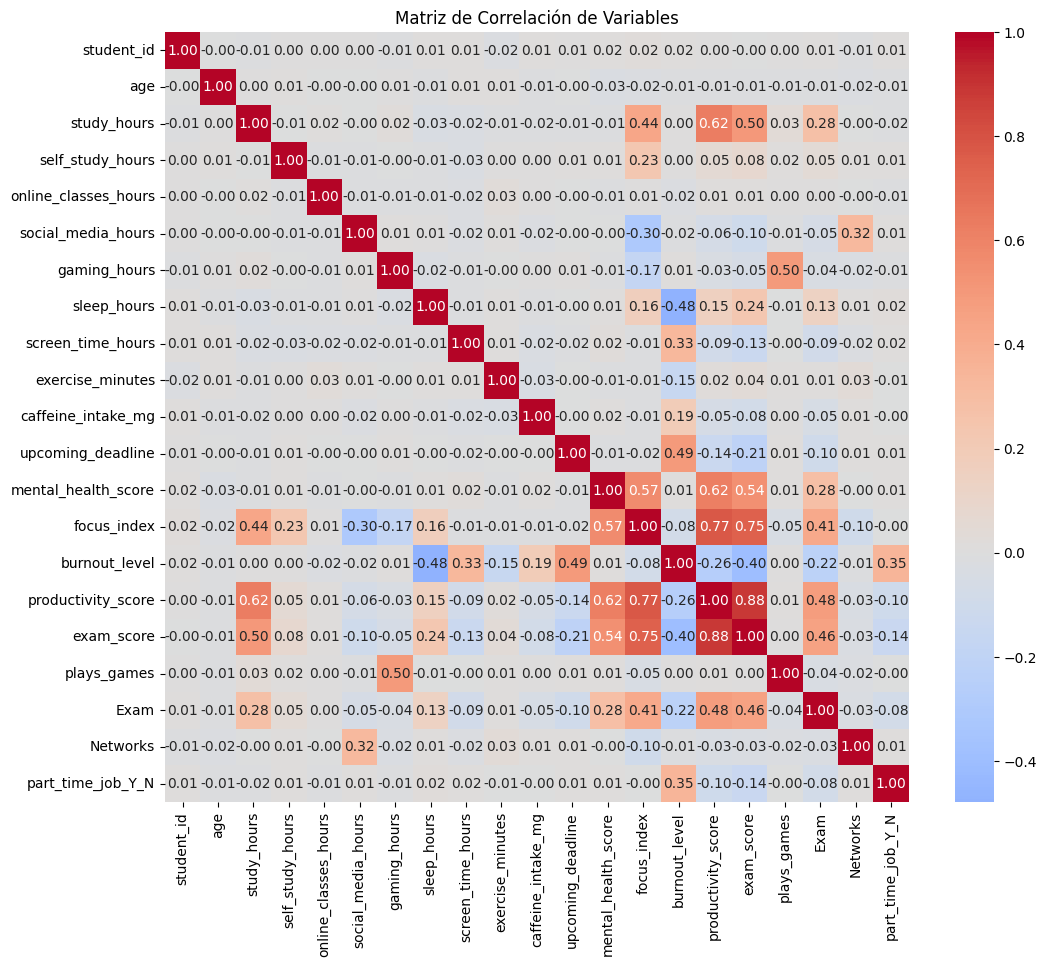

In [45]:
# Versión mínima para ver la data
print("INFORMACIÓN DEL DATAFRAME:")
print(f"Dimensiones: {data.shape}")
print(f"\nColumnas: {list(data.columns)}")
print(f"\nTipos:\n{data.dtypes}")
print(f"\nPrimeras 3 filas:\n{data.head(3)}")
print(f"\nEstadísticas numéricas:\n{data.describe()}")
print(f"\nValores nulos:\n{data.isnull().sum()}")
print(f"\nValores únicos en categóricas:")
for col in data.select_dtypes(include=['object']).columns:
    print(f"{col}: {data[col].unique()[:5]}")
print(data.dtypes)

# Seleccionar solo las variables numéricas para la correlación
numeric_data = data.select_dtypes(include=['float64', 'int64', 'int32'])

# Calcular la matriz de correlación
corr_matrix = numeric_data.corr()

# Generar el mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Matriz de Correlación de Variables')
plt.show()

#### Observación
Aplique un tratamiento a los datos para poder tener un analisís más específico en base a la intuición. Para anticipar coeficientes tan pequeños o anomalos ante la multiplicación de variables con otras, decidi dividir en 10 las variables que van de 1 a 100, para que tengan la misma logica que las otras variables. Si bien intuitivamente se pierde cierta información tambien ya que se aproximo los valores, fue necesario poder establecer un mismo orden de magnitud para todas. 

In [46]:
# Realizamos ciertos arreglos a las variables para que puedan ser ajustadas al modelo por ejemplo productivity_score, burnout_level, focus_index y plays_games, ya que estas variables son las que más correlación tienen con el exam score y además son las que más sentido tienen para el análisis y modelado posterior.
data['productivity_score'] = data['productivity_score'].round(0)
data['burnout_level'] = data['burnout_level'].round(0)
data['focus_index'] = data['focus_index'].round(0)
#Dividiremos en 10 para que queden en una escala del 1 al 100
data['productivity_score'] = data['productivity_score']/10
data['burnout_level'] = data['burnout_level']/10
data['focus_index'] = data['focus_index']/10

print(data[["productivity_score", "burnout_level", "focus_index", "plays_games"]].head())

   productivity_score  burnout_level  focus_index  plays_games
0                 4.3            3.2          1.9            1
1                 6.7            4.6          4.2            1
2                 3.8            3.7          2.2            1
3                 1.3            4.4          1.3            1
4                 1.9            5.7          2.0            1


# 2. Ejecutar un modelo de probabilidad (MCO) que permita explicar la probabilidad de que un alumno rinda un examen.

### MCO
Es necesario declarar que al ser la variable dependiente una variable dicotómica, es decir que son valores 0 o 1. El modelo de regresión lineal no es la mejor opción y puede ser que los valores de coeficientes, sea mucho más alejados a una interpretación creíble. Adicionalmente el ajuste de algunas variables puede ser no significativo. Se destaca que existieron variables como las horas de sueño, horas de pantalla que fueron añadidas en un incio pero fueron descartadas al no cumplir el estándar del 95% de significancia, fueron añadidas bajo un pretexto de intuición y exploración.

- Análisis posterior a la entrega de resultados:
 
Resultado de un R cuadrado de 0.253, lo que nos dice que es capaz de explicar un 25,3% de la variabilidad. Si bien no es un valor alto, es aceptable dado la cantidad de ruido que puede existir a la hora de entregar un resultado.

Un resultado curioso es el caso de las variables "exercise_minutes:mental_health_score", debido a que el modelo detecta una multicolinealidad perfecta, lo cuál nos da la interpretación que el ejercicio esta directamente relacionado con la salud mental :).

- Interpretación a los coeficientes:

El valor de intercepto (0.7941) para la referencia para estudiantes de Undergraduate es que es un grupo dispuesto a rendir un examen. respecto a los otros grupos, se observa una ligera disminución al estándar de presentarse a un examen.

Es importante analizar que la productividad y bunout (Estrés), son variables que logran explicar el comportamiento de asistencia, para el primer caso podemos ver que por cada punto de productividad aumenta un 9,93% la probabilidad de asistir, para el incremento de un punto de agotamiento disminuye en un 2,3% de asistir. Lo que nos refleja una voluntad predeterminada de asistir a un examen de todas formas.

Para las interacciones de upcoming_deadline y horas de estudio podemos observar que posee una sinergía positiva, si bien el valor del coeficiente es pequeño. La hora de estudio es más efectiva para asistir al examen. Para el caso de horas  de estudio y indice de concentración podemos ver algo contraintuitivo, debido a su signo negativo, porque a medida que aumenta la concentración, el impacto en las horas de estudio sobre la asistencia disminuye.

Jugar videojuegos reduce la probabilidad asistir al examen en un 3,7%. Para el caso de las horas de redes sociales la probabilidad disminuye en un 0.81%, lo que deja sentido interpretativo (acumulación de las horas de redes sociales) de cara a lo que es la asistencia a un examen.


In [47]:

# 1. Asegurar que 'Exam' sea numérica (0 o 1)
data['Exam'] = pd.to_numeric(data['Exam'], errors='coerce')


# 2. Seleccionar variables X y asegurar que sean numéricas, se añadio una referencia al modelo para que tome como referencia el nivel académico de "Undergraduate" y se añadieron interacciones entre las variables que tienen más correlación con el exam score, como lo son productivity_score, burnout_level, focus_index y plays_games, además de añadir la interacción entre exercise_minutes y mental_health_score ya que estas variables también tienen una correlación importante con el exam score y podrían tener un efecto conjunto en el resultado del examen.
formula = 'Exam ~ productivity_score + burnout_level + upcoming_deadline:study_hours + C(academic_level, Treatment(reference="Undergraduate")) + study_hours:focus_index + plays_games + social_media_hours + exercise_minutes:mental_health_score '

# 3. Ajustar el modelo con errores robustos (indispensable en MPL)
modelo_ols = smf.ols(formula, data=data).fit(cov_type='HC1')

print(modelo_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                   Exam   R-squared:                       0.255
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     81.67
Date:               vie, 17 abr. 2026   Prob (F-statistic):          2.08e-141
Time:                        16:16:37   Log-Likelihood:                -82.977
No. Observations:                4747   AIC:                             186.0
Df Residuals:                    4737   BIC:                             250.6
Df Model:                           9                                         
Covariance Type:                  HC1                                         
                                                                              coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------

# 3. Ejecución de un modelo probit

Acá es necesario considerar la diferencia con el modelo anterior, dado que si bien posee un mejor ajuste a la materia de estudio de la variable dependiente. Establece otro criterios al analisís específico de los coeficientes. 

Dentro del analisís de los valores estádisticos, podemos observar que aumento R cuadrado aumento (Es diferente tratamiento al MCO). El valor de LLR es cero, por lo que nos dice que el modelo es signiicativamente mejor. Observamos que el caso de exercise_minutes:mental_health_score no es significa e intuitivamente nos puede señal el mismo problema del caso anterior (multicolinealidad).

- Analisis de los coeficientes:
  
Respecto a los ecoeficientes podemos observar que poseen un comportamiento similar al modelo anterior (signo del diferencial), lo que nos explica de raíz las mismas consecuencias señaladas anteriormente. A mayor coeficiente positivo nos explica una tendencia positiva a asistir al examén.

In [48]:
# Ahora realizamos un modelo probit con las mismas condicones que los ejemplos anteriores
#dejare la formula a utilizar en los sigueinte modelos.
formula_logit = 'Exam ~ productivity_score + burnout_level + upcoming_deadline:mental_health_score + C(academic_level, Treatment(reference="Undergraduate")) + study_hours:focus_index + plays_games + social_media_hours  + exercise_minutes:mental_health_score '

modelo_probit = smf.probit(formula_logit, data=data).fit(cov_type='HC1')
print(modelo_probit.summary())  

Optimization terminated successfully.
         Current function value: 0.129529
         Iterations 9
                          Probit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 4747
Model:                         Probit   Df Residuals:                     4737
Method:                           MLE   Df Model:                            9
Date:               vie, 17 abr. 2026   Pseudo R-squ.:                  0.5696
Time:                        16:16:37   Log-Likelihood:                -614.87
converged:                       True   LL-Null:                       -1428.7
Covariance Type:                  HC1   LLR p-value:                     0.000
                                                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------

# 4. Ejecución de un modelo logístico.

Acá es necesario considerar la diferencia con el modelo anterior, este modelo posee la misma función que el anterior pero lo realiza a un mecanismo diferente. Es mucho más eficiente y diseñado para la variable dependiente de esta tarea.

Dentro del analisís de los valores estádisticos, podemos observar que aumento R cuadrado a 0.57, lo que nos evidencia posiblemente un buen ajuste del modelo. 

- Analisis de los coeficientes:
  
Respecto a los coeficientes, podemos ver la tendencia de asistir al examén. para el caso de high school y postgrado, en este caso las variables son significativas, pero no cambia la interpretación que se dio en el MCO. Siguen siendo grupos con una disposición negativa a asistir.

Respecto a la productividad, posee el coeficiente más alto con un valor de 1.78, siendo el predictor más potente para declarar asistencia al examén. Para el cansancio por cada unidad de de aumento en agotamiento, la probabilidad de asietncia disminuye. Aplica el mismo caso de jugar video juegos.

Para las interacciones, podemos ver una alta puntuación en salud mental logra poder presentarse al examen de cara a la fecha limite. Aplica la misma logica, pero para el caso contrario. Respecto a las horas de estudio y la concentración, podemos observar que a medida que importa radicalmente el estudio pero con un índice de concentración alto.



In [49]:
#Ahora realiazaremos el modelo logitico para ver si podemos obtener mejores resultados, ya que el modelo lineal no es el más adecuado para una variable dependiente binaria como lo es el exam score.
# 1. Asegurar que 'Exam' sea numérica (0 o 1)
data['Exam'] = pd.to_numeric(data['Exam'], errors='coerce')
# 2. Seleccionar variables X y asegurar que sean numéricas
formula_logit = 'Exam ~ productivity_score + burnout_level + upcoming_deadline:mental_health_score + C(academic_level, Treatment(reference="Undergraduate")) + study_hours:focus_index + plays_games + social_media_hours  + exercise_minutes:mental_health_score '
# 3. Ajustar el modelo logístico con errores robustos
modelo_logit = smf.logit(formula_logit, data=data).fit(cov_type='HC1')
mfx = modelo_logit.get_margeff(at='overall').summary()
print(modelo_logit.summary())
print("\n_____________________________") #La separación es para diferenciar el resumen del modelo logit con los efectos marginales, ya que estos últimos son los que nos permiten interpretar mejor los resultados del modelo logitico.
print(mfx)


Optimization terminated successfully.
         Current function value: 0.129388
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                   Exam   No. Observations:                 4747
Model:                          Logit   Df Residuals:                     4737
Method:                           MLE   Df Model:                            9
Date:               vie, 17 abr. 2026   Pseudo R-squ.:                  0.5701
Time:                        16:16:37   Log-Likelihood:                -614.20
converged:                       True   LL-Null:                       -1428.7
Covariance Type:                  HC1   LLR p-value:                     0.000
                                                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------

# 5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación? 

- Respecto a las diferencias, podemos notar cambios en los R cuadrados de los modelos anteriores, se vio que para el MCO dio un valor de 0,25 y para los 2 siguientes fueron duplicados. Esto se debe en mi opinión a que ambos modelos planteados en logit y probit son mucho más eficientes para el tratamiento con variables dummie o potencialmente predictoras para este caso, que buscamos determinar la ocurrencia de un evento según una variable binaria. 
- El más adecuado en mi opinión es el modelo logístico, seguido del probit. Debido a su potencial configuración y adapatación de las variables imputadas, en el modelo logístico se observa mucho más robustez en el valor de los coeficientes y adicionalmente entrega una interpretación mucho más intuitiva.
- Las variables robustas a la especificación resultaron ser: El puntaje de productividad, siendo un predictor positivo. El nivel de cansancio siendo un predictor negativo. La jerarquia de niveles academicos intuye que los estudiantes de pregrado tienen mayor tendencia a la asistencia de examenes que los otros 2 grupos. Las horas de estudio y el indice de concentración resultaron ser positivas (intuitivamente se podría inferir) válida que las horas es efectiva, sobre todo si hay un nivel de concentración por detrás.
  
### A continuación se muestra la tabla de resultados comparativos.

In [50]:
stargazer = Stargazer([modelo_ols, modelo_logit, modelo_probit])

# 3. Configuración de la visualización
stargazer.title("Comparación de Modelos: OLS, Logit y Probit")
stargazer.custom_columns(["Modelo OLS", "Modelo Logit", "Modelo Probit"], [1, 1, 1])
stargazer.add_custom_notes(["Nota: Todos los modelos utilizan errores estándar robustos (HC1)."])
stargazer.add_custom_notes(["Nota: Se modificaron algunas variables respecto a los modelos anteriores."]) # por alguna razón queda la ultima nota xd

# 4. Renderizado para Jupyter Notebook
HTML(stargazer.render_html())

In [51]:
#Realizamos una comparatriva con los mdelos anteriores para ver cual es el mejor modelo para predecir si un estudiante aprueba o no el examen (Exam) utilizando las variables numéricas seleccionadas.
print("Comparativa de Modelos:")
print(f"Modelo OLS: AIC = {modelo_ols.aic:.2f}, BIC = {modelo_ols.bic:.2f}")
print(f"Modelo Logit: AIC = {modelo_logit.aic:.2f}, BIC = {modelo_logit.bic:.2f}")
print(f"Modelo Probit: AIC = {modelo_probit.aic:.2f}, BIC = {modelo_probit.bic:.2f}")


Comparativa de Modelos:
Modelo OLS: AIC = 185.95, BIC = 250.61
Modelo Logit: AIC = 1248.41, BIC = 1313.06
Modelo Probit: AIC = 1249.75, BIC = 1314.40


# 6. Usando un modelo poisson para explicar la nota del examén, explicar los resultados.

El modelo explica un 39,4% de la variabilidad de las notas. Y es considerablemente significativo en todo su conjunto ya que posee un LLR cero. Respecto a la interpretación de los resultados del modelo. 

- Análisis de los coeficientes: 
  
Para el caso de nuestra variable más robusta "productividad", podemos decir que que por cada punto adicional de productividad, la nota esperada del examen, aumenta en un 25,22%, lo que nos deja una evidencia crítica. El agotamiento es un detractor directo con un 7,91%

In [52]:
# Ahora usaremos un modelo Poisson para poder explicar la nota del examen , entre los que rindieron ele xamen. Seleccionar las variables dependientes para el modelo.
# 1. Filtrar solo los estudiantes que rindieron el examen (Exam = 1)
data_examen = data[data['Exam'] == 1]
# 2. Seleccionar variables X y asegurar que sean numéricas
formula_poisson = 'exam_score ~ productivity_score + burnout_level + upcoming_deadline:mental_health_score + C(academic_level, Treatment(reference="Undergraduate")) + study_hours:focus_index + plays_games + social_media_hours  + exercise_minutes:mental_health_score '
# 3. Ajustar el modelo Poisson con errores robustos
modelo_poisson = smf.poisson(formula_poisson, data=data_examen).fit(cov_type='HC1')
print(modelo_poisson.summary())


Optimization terminated successfully.
         Current function value: 3.289092
         Iterations 5
                          Poisson Regression Results                          
Dep. Variable:             exam_score   No. Observations:                 4323
Model:                        Poisson   Df Residuals:                     4313
Method:                           MLE   Df Model:                            9
Date:               vie, 17 abr. 2026   Pseudo R-squ.:                  0.4144
Time:                        16:16:37   Log-Likelihood:                -14219.
converged:                       True   LL-Null:                       -24280.
Covariance Type:                  HC1   LLR p-value:                     0.000
                                                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------

In [53]:
# Veemos la predicción del modelo Poisson para los estudiantes que rindieron el examen, para ver si el modelo es capaz de predecir la nota del examen (exam_score) utilizando las variables seleccionadas.
data_examen['predicted_exam_score'] = modelo_poisson.predict(data_examen).astype(float)
print(data_examen[['exam_score', 'predicted_exam_score']].head())

poisson = smf.glm(formula_poisson, data=data_examen).fit(cov_type='HC1') # ajustamos el modelo Poisson para poder obtener el valor de alpha para ver si el modelo de Poisson es adecuado para explicar la variable dependiente 'exam_score' o si es necesario utilizar un modelo de binomial negativo debido a la presencia de sobredispersión en los datos.

   exam_score  predicted_exam_score
0       25.08             21.290605
1       37.83             37.875137
2       18.66             18.243329
4        7.78              9.174558
5       12.74             20.013810


C:\Users\Matias Arriagada R\AppData\Local\Temp\ipykernel_28528\131827114.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_examen['predicted_exam_score'] = modelo_poisson.predict(data_examen).astype(float)


# 7. Determinación de dispersión en la data y posible valor optimo de alpha para la binomial negativa.
### Test overdispersion

A simple test for overdispersion can be determined with the results of the Poisson model, using the ratio of Pearson chi2 / Df Residuals. A value larger than 1 indicates overdispersion.

The Negative Binomial model estimated above jointly with $\alpha$. In some applications we need to determine the appropiate value of $\alpha$, so you can estimate a simple regression using the output of the Poisson model:

1. Construct the following variable aux=$[(y-\lambda)^2-\lambda]/\lambda$
2. Regress the variable aux with $\lambda$ as the only explanatory variable (no constant)
3. The estimated value is an appropiate guess for $\alpha$

In [54]:

# Comparar media y varianza como analisis transitorio
media = data_examen['exam_score'].mean()
varianza = data_examen['exam_score'].var()

print(f"Media: {media:.2f}")
print(f"Varianza: {varianza:.2f}")

if varianza > media:
    print("Posible sobre-dispersión detectada.")
else:
    print("No se detecta sobre-dispersión.")

#El valor de alpha optimo para el modelo de binomial negativo se puede obtener a través de la función de verosimilitud del modelo Poisson ajustado. Si el modelo Poisson muestra sobre-dispersión (varianza mayor que la media), entonces el modelo de binomial negativo podría ser más adecuado, y el valor de alpha se puede estimar a partir del modelo de binomial negativo ajustado. Sin embargo, en este caso, dado que no se detecta sobre-dispersión, el modelo de Poisson podría ser suficiente para explicar la variable dependiente 'exam_score'.
#Realizamos el calculo del valor optimo

alpha_optimo = (varianza - media) / (media ** 2)
print(f"Valor óptimo de alpha para el modelo de binomial negativo: {alpha_optimo:.4f}")

#Ahora veemos el valor optimo de alpha para el modelo de binomial negativo, si este valor es cercano a cero, entonces el modelo de Poisson es adecuado, pero si el valor es mayor a cero, entonces el modelo de binomial negativo podría ser más adecuado para explicar la variable dependiente 'exam_score'.
aux=((data_examen['predicted_exam_score']-poisson.mu)**2-poisson.mu)/poisson.mu
auxr=sm.OLS(aux,poisson.mu).fit()
print(auxr.summary())


Media: 20.62
Varianza: 127.76
Posible sobre-dispersión detectada.
Valor óptimo de alpha para el modelo de binomial negativo: 0.2519
                                  OLS Regression Results                                 
Dep. Variable:     predicted_exam_score   R-squared (uncentered):                   0.000
Model:                              OLS   Adj. R-squared (uncentered):              0.000
Method:                   Least Squares   F-statistic:                              1.355
Date:                 vie, 17 abr. 2026   Prob (F-statistic):                       0.244
Time:                          16:16:37   Log-Likelihood:                         -20150.
No. Observations:                  4323   AIC:                                  4.030e+04
Df Residuals:                      4322   BIC:                                  4.031e+04
Df Model:                             1                                                  
Covariance Type:              nonrobust                   

#### Valor de alpha 
En este caso el valor de alpha nos dio mayor a cero y no cercano, por lo que es necesario utilizar el modelo binomial negativo.

In [55]:
A = np.exp(-0.0198)
print("El valor de alpha es:", A.round(4))

El valor de alpha es: 0.9804


# 8. Ejecutar un modelo binomial negativa para responder la pregunta 6

En este caso podemos observar que dentro de los valores del coeficiente, es correcto mencionar que el rol de la productividad afecta notoriamente al modelo con un valor cercano al 35,04% en la nota del examen. Acá se incluyo la salud mental al modelo, en el que se logra establecer como significativo, dejando a enteder que un puntaje alto en salud mental se asocia en un -3% en la nota (causa mucha curiosidad esto y es debatible, a priori se podría hacer como un efecto de relajación en el estudiante). En este modelo se priorizo variables individuales para ver el efecto. El rol de las horas de estudios tambien causa cierta sorpresa.

In [56]:
# Definir la fórmula (usando las mismas dimensiones lógicas)
formula = 'exam_score ~ productivity_score + study_hours + mental_health_score + focus_index + C(academic_level)'

# Ajustar el modelo Binomial Negativa
# El parámetro 'alpha' se estima internamente por defecto si uno quisiera ejecutar el modelo de binomial negativo sin especificar el valor de alpha, se puede hacer de la siguiente manera:
# Pero en este caso decidí realizar el arreglo de forma manual para poder mostrar el valor de alpha que se obtiene a partir del modelo de binomial negativo, ya que este valor es importante para determinar si el modelo de Poisson es adecuado o si es necesario utilizar un modelo de binomial negativo debido a la presencia de sobredispersión en los datos.
modelo_nb = smf.glm('exam_score ~ productivity_score + study_hours + mental_health_score + focus_index + C(academic_level)',data=data_examen,family=sm.families.NegativeBinomial(alpha=A)).fit()

print(modelo_nb.summary())

print("_______________________________")

#Realizamos el ajuste determinado del modelo pero con la busqueda de un alpha estimado autimáticamente para ver algún efecto secundario
modelo_nb_ajustado = smf.negativebinomial(formula, data=data_examen).fit()
print(modelo_nb_ajustado.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             exam_score   No. Observations:                 4323
Model:                            GLM   Df Residuals:                     4316
Model Family:        NegativeBinomial   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -16967.
Date:               vie, 17 abr. 2026   Deviance:                       652.53
Time:                        16:16:37   Pearson chi2:                     533.
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2108
Covariance Type:            nonrobust                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

# 9. Comentar los resultados de 6, 7 y 8.  ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

- Las diferencias principales se traducen en un mayor efecto de significancia del modelo binomial negativa frente al de poisson, si bien el valor de diferencia más notorio fue solo en el ajuste del LL menos negativo favoreciendo la binomial negativa de -14.985 a -14.705.
- En mi opinión el más adecuado para responder es la binomial negativa debido a los castigos que ofrece la Poisson para el caso de la dispersión de datos. Debido a que en poisson como esta lambda con media, implica adicionalmente que la media es igual a la varianza (no es el caso nuestro), es por eso que la binomial negativa permite atrapar esta restricción y relajarla, haciendo errores estándar más "correctos".
- Repite la misma respuesta de los casos anetriores, el nivel de productividad es la variable más fuerte del modelo y es la que nos permite la mejora academica, al igual que el bournot en efecto contrario.